# Workshop-1 - Adding Sunglasses to Your Passport Photo Using OpenCV

# NAME: HEMANATH S
# REG NO: 212224230094

Face shape: (1280, 974, 3)


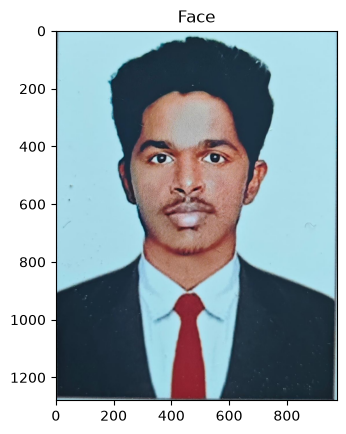

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load face image
faceImage = cv2.imread("img.jpg")
plt.imshow(faceImage[:,:,::-1]); plt.title("Face")
print("Face shape:", faceImage.shape)

Glass shape: (324, 735, 3)


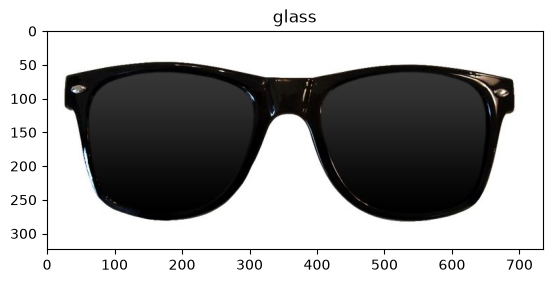

In [23]:
glass= cv2.imread("glass.png")
plt.imshow(glass[:,:,::-1]); plt.title("glass")
print("Glass shape:", glass.shape)

Text(0.5, 1.0, 'Sunglass Color channels')

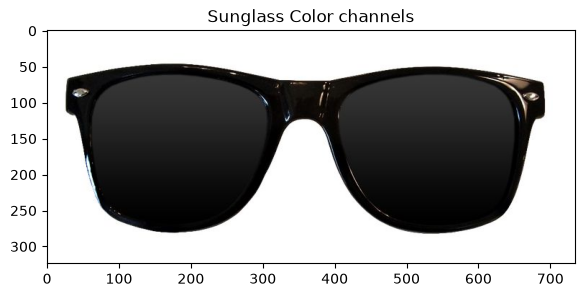

In [24]:
glassBGR = glass[:,:,0:3]
glassGray = cv2.cvtColor(glassBGR, cv2.COLOR_BGR2GRAY)
_, glassMask1 = cv2.threshold(glassGray, 240, 255, cv2.THRESH_BINARY_INV)  # detect non-white

plt.figure(figsize=[15,15])
#Show sunglasses color channels
plt.subplot(121)
plt.imshow(glassBGR[:,:,::-1])  # BGR → RGB
plt.title('Sunglass Color channels')

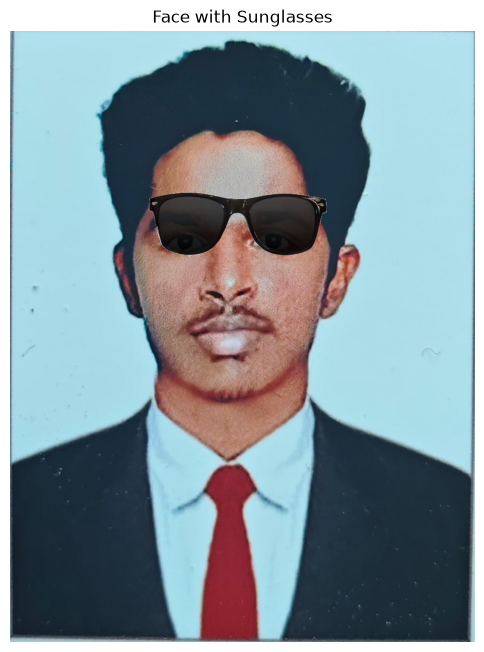

In [25]:
if faceImage is None or glass is None:
    raise ValueError("Error loading images")

face_h, face_w = faceImage.shape[:2]

# Resize glasses
new_w = int(face_w * 0.42)
new_h = int(glass.shape[0] * new_w / glass.shape[1])

glass_resized = cv2.resize(glass, (new_w, new_h))

# Position
x = int((face_w - new_w) / 2) - 5
y = int(face_h * 0.245)

# Make sure glasses stay inside face image
x = max(0, min(x, face_w - new_w))
y = max(0, min(y, face_h - new_h))

# Extract BGR channels
glass_rgb = glass_resized[:, :, :3]

# Create alpha channel
if glass_resized.shape[2] == 4:
    alpha = glass_resized[:, :, 3] / 255.0
else:
    
    # For PNG without alpha, create transparency from white background
    gray = cv2.cvtColor(glass_rgb, cv2.COLOR_BGR2GRAY)
    alpha = np.where(gray < 240, 1.0, 0.0)

# Slight transparency
alpha = alpha * 0.9

# Face ROI
roi = faceImage[y:y + new_h, x:x + new_w]

# Blend glasses with face
for c in range(3):
    roi[:, :, c] = (
        alpha * glass_rgb[:, :, c] +
        (1 - alpha) * roi[:, :, c]
    )

faceImage[y:y + new_h, x:x + new_w] = roi

# Display result
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(faceImage, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Face with Sunglasses")
plt.show()